In [1]:
# -*- coding: utf-8 -*-
"""
SynCodonLM evo scoring for sequences in a FASTA, with:

  (1) Non-synonym-constrained masked pseudo-likelihood (PLL)
  (2) Synonym-constrained masked pseudo-likelihood (PLL with synonym renorm)

UPDATED (per request):
  - Reads standard FASTA headers starting with ">" (not "&gt;")
  - Parses pipe-delimited influenza headers like:
      >PZ410101.1:1..1497 |nucleocapsid protein [Influenza A virus]|...|H3N2|...|2025-12-31
  - Filters to ONLY H3N2 records (drops non-H3N2)
  - Accession parsing trims coordinate suffixes like ":1..1497"
  - Year parsing prefers a terminal YYYY-MM-DD field when present
  - FASTA sequence lines can include inline comments after "#", which are ignored

Strict filters (current):
  1) Keep ONLY sequences that start with ATG; include ATG in scoring.
  2) Keep ONLY sequences that end in a stop codon; no internal stops; include terminal stop in scoring.
  3) Keep ONLY sequences with A/T/G/C (after cleaning).
  4) Keep ONLY sequences with year in [MIN_YEAR, MAX_YEAR] (inclusive); optionally drop missing year.
  5) Deduplicate by *protein sequence* (AA translation excluding terminal stop '*'):
       - Keep ONE representative per unique protein sequence
       - Drop the other records as "duplicate protein sequence"
       - In Scores sheet, add a column listing which accessions were dropped as duplicates
  6) Save undropped (kept representative) sequences to a fresh CSV.

Input : NPhumanH3N2.fasta.txt  (can be any FASTA now; H3N2 filter applied by header)
Output: np_evo_scores_2.xlsx (Scores + Dropped), np_evo_time_vs_score.png
        np_undropped_sequences.csv (kept representative sequences)

Notes:
- "Protein sequence" here is AA translation excluding the terminal stop '*'.
"""

import re
from typing import List, Dict, Optional, Tuple, Any
from collections import defaultdict, Counter

import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoConfig


# -------------------- Configuration --------------------
FASTA_PATH = "NAsequences.fasta"

MODEL_NAME = "./"  # local SynCodonLM folder
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# user requested token type id = 496
SPECIES_TOKEN_TYPE = 496

OUTPUT_XLSX = "np_evo_scores-ncbidataset-h1n1-NA.xlsx"
OUTPUT_PNG  = "np_evo_time_vs_score-h1n1-NA.png"

# write kept sequences (representatives after dedup)
OUTPUT_KEPT_CSV = "np_undropped_sequences-ncbidataset-h1n1-NA.csv"

# Prefilter controls
ALLOW_AMBIGUOUS_BASES = False  # if False: drop any non-ATGC after cleaning

# Year filter (inclusive)
MIN_YEAR = 1900
MAX_YEAR = 2026
DROP_IF_YEAR_MISSING = True

# NEW: subtype filter
TARGET_SUBTYPE = "H1N1"
DROP_IF_SUBTYPE_MISSING = True

# Plot controls
ANNOTATE_POINTS = True
MAX_ANNOTATIONS = 150

# Streaming packed batch controls (tune for L40S)
CHUNK_SIZE = 400          # try 1024 or 2048 on L40S; reduce if OOM
USE_AUTOCAST = True       # mixed precision inference on GPU
AUTOCAST_DTYPE = torch.bfloat16  # L40S supports bf16 well
# ------------------------------------------------------


# -------------------- Genetic code (fallback) --------------------
synonymous_codons = None
try:
    from utils import synonymous_codons as _syn
    synonymous_codons = _syn
except Exception:
    try:
        from SynCodonLM.utils import synonymous_codons as _syn
        synonymous_codons = _syn
    except Exception:
        pass

if synonymous_codons is None:
    synonymous_codons = {
        "A": ["GCT", "GCC", "GCA", "GCG"],
        "R": ["CGT", "CGC", "CGA", "CGG", "AGA", "AGG"],
        "N": ["AAT", "AAC"],
        "D": ["GAT", "GAC"],
        "C": ["TGT", "TGC"],
        "Q": ["CAA", "CAG"],
        "E": ["GAA", "GAG"],
        "G": ["GGT", "GGC", "GGA", "GGG"],
        "H": ["CAT", "CAC"],
        "I": ["ATT", "ATC", "ATA"],
        "L": ["TTA", "TTG", "CTT", "CTC", "CTA", "CTG"],
        "K": ["AAA", "AAG"],
        "M": ["ATG"],
        "F": ["TTT", "TTC"],
        "P": ["CCT", "CCC", "CCA", "CCG"],
        "S": ["TCT", "TCC", "TCA", "TCG", "AGT", "AGC"],
        "T": ["ACT", "ACC", "ACA", "ACG"],
        "W": ["TGG"],
        "Y": ["TAT", "TAC"],
        "V": ["GTT", "GTC", "GTA", "GTG"],
        "*": ["TAA", "TAG", "TGA"],
    }

STOP_CODONS = set(synonymous_codons["*"])

CODON_TO_AA: Dict[str, str] = {}
for aa, codons in synonymous_codons.items():
    for c in codons:
        CODON_TO_AA[c] = aa


# -------------------- Helpers --------------------
def clean_dna(seq: str) -> str:
    if not isinstance(seq, str):
        return ""
    # remove whitespace, uppercase, convert U->T
    return "".join(seq.split()).upper().replace("U", "T")

def dna_to_codons(seq: str) -> List[str]:
    if len(seq) % 3 != 0:
        raise ValueError(f"Sequence length {len(seq)} is not a multiple of 3.")
    return [seq[i:i+3] for i in range(0, len(seq), 3)]

def codons_to_aa(codons: List[str]) -> List[str]:
    aa_list = []
    for i, c in enumerate(codons):
        if c not in CODON_TO_AA:
            raise ValueError(f"Unknown codon '{c}' at codon index {i}.")
        aa_list.append(CODON_TO_AA[c])
    return aa_list

def gc_content(dna: str) -> float:
    dna = dna.upper()
    valid = [b for b in dna if b in ("A", "C", "G", "T")]
    if not valid:
        return float("nan")
    gc = sum(1 for b in valid if b in ("G", "C"))
    return gc / len(valid)

def gc3_content(dna: str) -> float:
    dna = dna.upper()
    if len(dna) < 3:
        return float("nan")
    thirds = dna[2::3]
    valid = [b for b in thirds if b in ("A", "C", "G", "T")]
    if not valid:
        return float("nan")
    gc = sum(1 for b in valid if b in ("G", "C"))
    return gc / len(valid)


# -------------------- Header parsing for pipe-delimited influenza FASTA --------------------
H_SUBTYPE_RE = re.compile(r"^H\d+N\d+$", re.IGNORECASE)
DATE_RE = re.compile(r"(?P<y>(19|20)\d{2})-(?P<m>\d{2})-(?P<d>\d{2})$")

def split_header_fields(header: str) -> List[str]:
    """
    Example header:
      >PZ410101.1:1..1497 |nucleocapsid protein [Influenza A virus]|Influenza A virus|...|H3N2|...|2025-12-31
    Split on '|' and trim whitespace.
    """
    h = header.strip()
    if h.startswith(">"):
        h = h[1:].strip()
    return [f.strip() for f in h.split("|")]

def parse_accession_from_header(header: str) -> str:
    """
    Takes the first field and trims coordinate suffixes like ':1..1497'.
    """
    fields = split_header_fields(header)
    first = fields[0] if fields else header.lstrip(">").strip()
    acc = first.split()[0]      # drop trailing whitespace tokens
    acc = acc.split(":")[0]     # drop coordinate suffix
    # If your data includes "cds:ACCESSION" style, keep backward compatibility:
    m = re.search(r"cds:([A-Za-z0-9_.-]+)", first)
    if m:
        return m.group(1)
    return acc

def parse_subtype_from_header(header: str) -> Optional[str]:
    """
    Returns subtype like 'H3N2' if present in any '|' field or anywhere in header.
    """
    fields = split_header_fields(header)
    for f in fields:
        ff = f.strip()
        if H_SUBTYPE_RE.match(ff):
            return ff.upper()
    m = re.search(r"\b(H\d+N\d+)\b", header, flags=re.IGNORECASE)
    return m.group(1).upper() if m else None

def parse_year_from_header(header: str) -> Optional[int]:
    """
    Prefer a terminal YYYY-MM-DD field if present.
    Otherwise fall back to first 4-digit year match.
    """
    fields = split_header_fields(header)
    if fields:
        last = fields[-1]
        m = DATE_RE.search(last)
        if m:
            return int(m.group("y"))
    m = re.search(r"(19|20)\d{2}", header)
    return int(m.group(0)) if m else None


def read_fasta(path: str) -> List[Tuple[str, str]]:
    """
    Standard FASTA reader:
      - headers begin with '>'
      - sequence lines are concatenated
      - inline comments after '#' are stripped (optional but handy)
    """
    records: List[Tuple[str, str]] = []
    header = None
    seq_lines: List[str] = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(seq_lines)))
                header = line
                seq_lines = []
            else:
                if "#" in line:
                    line = line.split("#", 1)[0].strip()
                if line:
                    seq_lines.append(line)
        if header is not None:
            records.append((header, "".join(seq_lines)))
    return records


# -------------------- Model setup --------------------
print("Loading SynCodonLM...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
config = AutoConfig.from_pretrained(MODEL_NAME)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME, config=config).to(DEVICE).eval()

bos_id = tokenizer.bos_token_id or tokenizer.cls_token_id
eos_id = tokenizer.eos_token_id or tokenizer.sep_token_id
mask_id = tokenizer.mask_token_id
if mask_id is None or bos_id is None or eos_id is None:
    raise ValueError("Tokenizer requires BOS/EOS and MASK tokens.")

supports_tti = "token_type_ids" in getattr(tokenizer, "model_input_names", [])
UNK = tokenizer.unk_token_id

pad_id = tokenizer.pad_token_id
if pad_id is None:
    pad_id = eos_id

# AA -> token ids for synonymous codons in tokenizer vocab
aa2ids: Dict[str, List[int]] = {}
for aa, codons in synonymous_codons.items():
    ids = []
    for codon in codons:
        cid = tokenizer.convert_tokens_to_ids(codon)
        if cid is not None and cid != UNK:
            ids.append(int(cid))
    aa2ids[aa] = sorted(set(ids))

def encode_codons_to_ids(codons: List[str]) -> List[int]:
    ids = []
    for i, c in enumerate(codons):
        cid = tokenizer.convert_tokens_to_ids(c)
        if cid is None or cid == UNK:
            raise ValueError(f"Codon '{c}' at codon index {i} not in tokenizer vocab.")
        ids.append(int(cid))
    return ids


# -------------------- Prefilter (STRICT + year range + subtype) --------------------
def prefilter_record(header: str, raw_seq: str) -> Tuple[Optional[Dict[str, Any]], Optional[str]]:
    dna = clean_dna(raw_seq)
    if not dna:
        return None, "empty sequence"

    acc = parse_accession_from_header(header)
    year = parse_year_from_header(header)

    # NEW: subtype filter (H3N2 only)
    subtype = parse_subtype_from_header(header)
    if subtype is None:
        if DROP_IF_SUBTYPE_MISSING:
            return None, "subtype missing/unparseable"
    else:
        if subtype.upper() != TARGET_SUBTYPE.upper():
            return None, f"non-target subtype: {subtype} (keeping only {TARGET_SUBTYPE})"

    # (4) Year filter: keep only [MIN_YEAR, MAX_YEAR], optionally drop missing year
    if year is None:
        if DROP_IF_YEAR_MISSING:
            return None, "year missing/unparseable"
    else:
        if year < MIN_YEAR or year > MAX_YEAR:
            return None, f"year {year} outside [{MIN_YEAR}, {MAX_YEAR}]"

    # (3) only ATGC
    if not ALLOW_AMBIGUOUS_BASES:
        bad_chars = sorted(set([b for b in dna if b not in ("A", "C", "G", "T")]))
        if bad_chars:
            return None, f"non-ATGC characters present: {''.join(bad_chars)[:50]}"

    if len(dna) % 3 != 0:
        return None, f"length {len(dna)} not multiple of 3"

    try:
        codons = dna_to_codons(dna)

        # (1) must start with ATG
        if not codons or codons[0] != "ATG":
            return None, "does not start with ATG"

        # (2) must end with stop codon
        if codons[-1] not in STOP_CODONS:
            return None, "does not end with stop codon (TAA/TAG/TGA)"

        # translate (for stop checks + synonym scoring)
        aa = codons_to_aa(codons)

        # (2) no internal stops; terminal must be stop
        if aa[-1] != "*":
            return None, "terminal codon is not a stop (translation mismatch)"
        if "*" in aa[:-1]:
            return None, "internal stop codon(s) present"

        ids = encode_codons_to_ids(codons)

    except Exception as e:
        return None, f"failed codon/AA/tokenize checks: {e}"

    # scoring includes ALL codons, including ATG and terminal stop
    L = len(ids)
    return {
        "header": header,
        "dna": dna,
        "acc": acc,
        "year": year,
        "subtype": subtype,
        "codons": codons,
        "aa": aa,
        "ids": ids,
        "expected_full": L,
        "expected_syn": L,   # synonym PLL over ALL positions
    }, None


# -------------------- Autocast context --------------------
def _autocast_ctx():
    if DEVICE.startswith("cuda") and USE_AUTOCAST:
        return torch.autocast(device_type="cuda", dtype=AUTOCAST_DTYPE)
    from contextlib import nullcontext
    return nullcontext()


# -------------------- Streaming packed task scoring --------------------
def iter_mixed_tasks(prepared: List[Dict[str, Any]]):
    """
    Yield tasks in sequence order:
      - all full-vocab PLL positions
      - then all synonym-constrained PLL positions

    NOTE: synonym PLL covers ALL positions (including ATG and terminal stop).
    """
    for sidx, item in enumerate(prepared):
        ids = item["ids"]
        aa = item["aa"]
        L = len(ids)

        # --- full vocab tasks (all positions) ---
        for pos in range(L):
            yield {
                "seq_idx": sidx,
                "pos": pos,
                "type": "full",
                "target": ids[pos],
                "aa": None,
                "seq_ids": ids,
            }

        # --- synonym constrained tasks (ALL positions) ---
        for pos in range(L):
            yield {
                "seq_idx": sidx,
                "pos": pos,
                "type": "syn",
                "target": ids[pos],
                "aa": aa[pos],
                "seq_ids": ids,
            }


@torch.no_grad()
def run_task_batch(tasks: List[Dict[str, Any]], species_tti: Optional[int]) -> List[Tuple[int, str, float]]:
    """
    Run one forward pass for a mixed batch of tasks across sequences.
    Returns list of (seq_idx, task_type, logp_value).
    """
    B = len(tasks)
    lengths = [len(t["seq_ids"]) for t in tasks]
    maxL = max(lengths)

    input_ids = torch.full((B, maxL + 2), pad_id, device=DEVICE, dtype=torch.long)
    attention_mask = torch.zeros((B, maxL + 2), device=DEVICE, dtype=torch.long)

    mask_positions = torch.empty((B,), device=DEVICE, dtype=torch.long)
    targets = torch.empty((B,), device=DEVICE, dtype=torch.long)

    seq_indices = [0] * B
    types = [""] * B
    aas = [None] * B

    for i, t in enumerate(tasks):
        sidx = int(t["seq_idx"])
        pos = int(t["pos"])
        ids = t["seq_ids"]
        L = len(ids)

        seq_indices[i] = sidx
        types[i] = t["type"]
        aas[i] = t["aa"]

        input_ids[i, 0] = bos_id
        input_ids[i, 1:1+L] = torch.tensor(ids, device=DEVICE, dtype=torch.long)
        input_ids[i, 1+L] = eos_id
        attention_mask[i, :L+2] = 1

        input_ids[i, pos + 1] = mask_id
        mask_positions[i] = pos + 1
        targets[i] = int(t["target"])

    batch = {"input_ids": input_ids, "attention_mask": attention_mask}
    if supports_tti and species_tti is not None:
        batch["token_type_ids"] = torch.full_like(input_ids, int(species_tti))

    with _autocast_ctx():
        logits = model(**batch).logits

    rows = logits[torch.arange(B, device=DEVICE), mask_positions, :].float()
    logZ_full = torch.logsumexp(rows, dim=-1)

    out: List[Tuple[int, str, float]] = []
    for i in range(B):
        sidx = seq_indices[i]
        ttype = types[i]
        target_id = int(targets[i].item())

        if ttype == "full":
            lp = rows[i, target_id] - logZ_full[i]
            out.append((sidx, "full", float(lp.item())))
        else:
            aa = aas[i]
            cand = aa2ids.get(aa, []) if aa is not None else []

            # If we can't constrain, fall back to full-vocab
            if not cand:
                lp = rows[i, target_id] - logZ_full[i]
                out.append((sidx, "syn", float(lp.item())))
                continue

            if target_id not in cand:
                cand = cand + [target_id]

            cand_t = torch.tensor(cand, device=DEVICE, dtype=torch.long)
            sub = rows[i].index_select(0, cand_t)
            logZ_sub = torch.logsumexp(sub, dim=-1)
            idx = cand.index(target_id)
            lp = sub[idx] - logZ_sub
            out.append((sidx, "syn", float(lp.item())))

    return out


def score_all_sequences_stream_packed(prepared: List[Dict[str, Any]], chunk_size: int, species_tti: Optional[int]):
    nseq = len(prepared)
    full_sum = [0.0] * nseq
    syn_sum = [0.0] * nseq
    full_cnt = [0] * nseq
    syn_cnt = [0] * nseq

    exp_full = [int(item["expected_full"]) for item in prepared]
    exp_syn  = [int(item["expected_syn"])  for item in prepared]

    done = [False] * nseq
    done_count = 0

    pbar = tqdm(total=nseq, desc="Scoring FASTA sequences", unit="seq")

    batch: List[Dict[str, Any]] = []
    for task in iter_mixed_tasks(prepared):
        batch.append(task)
        if len(batch) >= chunk_size:
            results = run_task_batch(batch, species_tti)
            for sidx, ttype, lp in results:
                if ttype == "full":
                    full_sum[sidx] += lp
                    full_cnt[sidx] += 1
                else:
                    syn_sum[sidx] += lp
                    syn_cnt[sidx] += 1

            newly_done = 0
            for i in range(nseq):
                if done[i]:
                    continue
                if full_cnt[i] >= exp_full[i] and syn_cnt[i] >= exp_syn[i]:
                    done[i] = True
                    newly_done += 1
            if newly_done:
                done_count += newly_done
                pbar.update(newly_done)
                pbar.set_postfix_str(f"done {done_count}/{nseq}")

            batch = []

    if batch:
        results = run_task_batch(batch, species_tti)
        for sidx, ttype, lp in results:
            if ttype == "full":
                full_sum[sidx] += lp
                full_cnt[sidx] += 1
            else:
                syn_sum[sidx] += lp
                syn_cnt[sidx] += 1

        newly_done = 0
        for i in range(nseq):
            if done[i]:
                continue
            if full_cnt[i] >= exp_full[i] and syn_cnt[i] >= exp_syn[i]:
                done[i] = True
                newly_done += 1
        if newly_done:
            done_count += newly_done
            pbar.update(newly_done)
            pbar.set_postfix_str(f"done {done_count}/{nseq}")

    pbar.close()

    full_mean = [full_sum[i] / max(1, full_cnt[i]) for i in range(nseq)]
    syn_mean  = [syn_sum[i]  / max(1, syn_cnt[i])  for i in range(nseq)]
    return full_mean, syn_mean, full_cnt, syn_cnt


# -------------------- Main --------------------
records = read_fasta(FASTA_PATH)
if not records:
    raise RuntimeError(f"No FASTA records found in {FASTA_PATH}")

prepared: List[Dict[str, Any]] = []
dropped: List[Dict[str, Any]] = []

print("Pre-parsing & filtering FASTA records...")
for header, seq in tqdm(records, desc="Parsing FASTA", unit="seq"):
    item, reason = prefilter_record(header, seq)
    if item is None:
        dna_clean = clean_dna(seq)
        dropped.append({
            "accession": parse_accession_from_header(header),
            "year": parse_year_from_header(header),
            "subtype": parse_subtype_from_header(header),
            "header": header.lstrip(">").strip(),
            "length_nt_raw": len(dna_clean),
            "reason": reason,
        })
        continue
    prepared.append(item)

print(f"[INFO] Kept {len(prepared)} record(s); dropped {len(dropped)} record(s).")

# -------------------- Deduplicate by protein sequence --------------------
# Define "protein sequence" as AA translation excluding terminal stop "*"
for item in prepared:
    item["protein"] = "".join(item["aa"][:-1])

# Summary of duplicates BEFORE dedup
proteins_all = [item["protein"] for item in prepared]
counts = Counter(proteins_all)
n_total = len(proteins_all)
n_unique = len(counts)
n_dup_groups = sum(1 for v in counts.values() if v > 1)
n_dup_records = sum(v for v in counts.values() if v > 1)
n_extra_copies = sum(v - 1 for v in counts.values() if v > 1)

print(
    "[DUP] Protein duplicates among prefilter-KEPT records:\n"
    f"      total kept proteins      = {n_total}\n"
    f"      unique proteins          = {n_unique}\n"
    f"      duplicated protein groups= {n_dup_groups}\n"
    f"      records in dup groups    = {n_dup_records}\n"
    f"      extra duplicate copies   = {n_extra_copies}"
)

prot_to_items = defaultdict(list)
for item in prepared:
    prot_to_items[item["protein"]].append(item)

# Choose one representative per protein group (deterministic):
# earliest year first (None last), then accession
def _rep_sort_key(x):
    y = x["year"]
    return (y is None, y if y is not None else 10**9, x["acc"])

dedup_prepared = []
dedup_dropped = []

for prot, items in prot_to_items.items():
    items_sorted = sorted(items, key=_rep_sort_key)
    rep = items_sorted[0]
    others = items_sorted[1:]

    # record who was dropped for this representative
    rep["dup_n_total"] = len(items_sorted)
    rep["dup_n_dropped"] = len(others)
    rep["dup_accessions_dropped"] = ";".join([o["acc"] for o in others])

    dedup_prepared.append(rep)

    # push duplicates into dropped list (so they appear in Dropped sheet)
    for o in others:
        dedup_dropped.append({
            "accession": o["acc"],
            "year": o["year"],
            "subtype": o.get("subtype"),
            "header": o["header"].lstrip(">").strip(),
            "length_nt_raw": len(o["dna"]),
            "reason": f"duplicate protein sequence (same as representative {rep['acc']})",
            "duplicate_of": rep["acc"],
        })

# Replace prepared with deduplicated representatives
prepared = sorted(dedup_prepared, key=_rep_sort_key)

# Extend the dropped list with protein-duplicate drops
dropped.extend(dedup_dropped)

print(
    f"[INFO] After protein dedup: kept {len(prepared)} representative(s); "
    f"added {len(dedup_dropped)} duplicate-protein record(s) to dropped."
)
# ------------------------------------------------------------------------


# Save kept (representative) sequences to a fresh CSV
if prepared:
    kept_rows = []
    for item in prepared:
        kept_rows.append({
            "accession": item["acc"],
            "year": item["year"],
            "subtype": item.get("subtype"),
            "header": item["header"].lstrip(">").strip(),
            "dna": item["dna"],
            "length_nt": len(item["dna"]),
            "length_codons": len(item["codons"]),
            "start_codon": item["codons"][0],
            "terminal_codon": item["codons"][-1],
            "gc": gc_content(item["dna"]),
            "gc3": gc3_content(item["dna"]),
            # protein + dedup annotations
            "protein_sequence": item.get("protein", ""),
            "protein_group_size": int(item.get("dup_n_total", 1)),
            "duplicate_protein_dropped_samples": item.get("dup_accessions_dropped", ""),
        })
    pd.DataFrame(kept_rows).sort_values(["year", "accession"], na_position="last").to_csv(
        OUTPUT_KEPT_CSV, index=False
    )
    print(f"[OK] Wrote kept representative sequences to {OUTPUT_KEPT_CSV}")

if not prepared:
    with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as w:
        pd.DataFrame(dropped).to_excel(w, index=False, sheet_name="Dropped")
    print(f"[OK] No valid records to score. Wrote dropped list to {OUTPUT_XLSX}.")
    raise SystemExit(0)

# Score everything with stream-packed batching (representatives only)
full_means, syn_means, full_cnt, syn_cnt = score_all_sequences_stream_packed(
    prepared, chunk_size=CHUNK_SIZE, species_tti=SPECIES_TOKEN_TYPE
)

# Assemble rows (Scores sheet)
rows: List[Dict[str, Any]] = []
for i, item in enumerate(prepared):
    dna = item["dna"]
    rows.append({
        "accession": item["acc"],
        "year": item["year"],
        "subtype": item.get("subtype"),
        "header": item["header"].lstrip(">").strip(),
        "length_nt": len(dna),
        "length_codons": len(item["codons"]),
        "start_codon": item["codons"][0],
        "terminal_codon": item["codons"][-1],
        "gc": gc_content(dna),
        "gc3": gc3_content(dna),

        # protein + dedup annotations
        "protein_sequence": item.get("protein", ""),
        "protein_group_size": int(item.get("dup_n_total", 1)),
        "duplicate_protein_dropped_samples": item.get("dup_accessions_dropped", ""),

        "evo_full_vocab_PLL": full_means[i],
        "evo_synonym_constrained_PLL": syn_means[i],
        "delta_syn_minus_full": syn_means[i] - full_means[i],
        "full_sites_scored": full_cnt[i],
        "syn_sites_scored": syn_cnt[i],
        "chunk_size": CHUNK_SIZE,
        "autocast": bool(USE_AUTOCAST),
        "autocast_dtype": str(AUTOCAST_DTYPE).replace("torch.", ""),
        "year_filter_min": MIN_YEAR,
        "year_filter_max": MAX_YEAR,
        "target_subtype": TARGET_SUBTYPE,
    })

df = pd.DataFrame(rows)
df_dropped = pd.DataFrame(dropped)

# Write Excel (Scores + Dropped)
with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as w:
    if not df.empty:
        df.sort_values(["year", "accession"], na_position="last").to_excel(
            w, index=False, sheet_name="Scores"
        )
    if not df_dropped.empty:
        sort_cols = [c for c in ["year", "accession"] if c in df_dropped.columns]
        df_dropped.sort_values(sort_cols, na_position="last").to_excel(
            w, index=False, sheet_name="Dropped"
        )

print(f"[OK] Wrote {OUTPUT_XLSX}")

# Plot: Year vs evo score (representatives only)
df_plot = df.dropna(subset=["year"]).copy().sort_values("year")
if df_plot.empty:
    print("[WARN] No scored rows with a parsed year; skipping plot.")
else:
    years = df_plot["year"].astype(int).values
    sizes = (df_plot["length_codons"].astype(float).values * 0.25) + 15.0
    colors = df_plot["gc3"].astype(float).values

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sc1 = ax.scatter(
        years,
        df_plot["evo_full_vocab_PLL"].values,
        c=colors,
        s=sizes,
        marker="o",
        alpha=0.80,
        label="Non-syn constrained (PLL, stream-packed)",
    )
    ax.scatter(
        years,
        df_plot["evo_synonym_constrained_PLL"].values,
        c=colors,
        s=sizes,
        marker="s",
        alpha=0.80,
        label="Synonym constrained (PLL, stream-packed)",
    )

    cbar = fig.colorbar(sc1, ax=ax)
    cbar.set_label("GC3")

    ax.set_xlabel("Year")
    ax.set_ylabel("Evo score (mean log-prob, nats)")
    ax.set_title(f"NA (Human {TARGET_SUBTYPE}) — SynCodonLM evo score vs time (color=GC3, size=length)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

    if ANNOTATE_POINTS:
        n_anno = min(len(df_plot), MAX_ANNOTATIONS)
        for j in range(n_anno):
            r = df_plot.iloc[j]
            ax.annotate(
                str(r["accession"]),
                (int(r["year"]), float(r["evo_full_vocab_PLL"])),
                textcoords="offset points",
                xytext=(4, 3),
                fontsize=7,
                alpha=0.60,
            )

    plt.tight_layout()
    plt.savefig(OUTPUT_PNG, dpi=200)
    plt.close(fig)
    print(f"[OK] Saved {OUTPUT_PNG}")

Loading SynCodonLM...
Pre-parsing & filtering FASTA records...


Parsing FASTA:   0%|          | 0/122462 [00:00<?, ?seq/s]

[INFO] Kept 16940 record(s); dropped 105522 record(s).
[DUP] Protein duplicates among prefilter-KEPT records:
      total kept proteins      = 16940
      unique proteins          = 4744
      duplicated protein groups= 1239
      records in dup groups    = 13435
      extra duplicate copies   = 12196
[INFO] After protein dedup: kept 4744 representative(s); added 12196 duplicate-protein record(s) to dropped.
[OK] Wrote kept representative sequences to np_undropped_sequences-ncbidataset-h1n1-NA.csv


Scoring FASTA sequences:   0%|          | 0/4744 [00:00<?, ?seq/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[OK] Wrote np_evo_scores-ncbidataset-h1n1-NA.xlsx
[OK] Saved np_evo_time_vs_score-h1n1-NA.png


In [2]:
# ===== Cell A: Reload Excel into df, rebuild strain-like labels from FASTA,
# =====         fix year parsing, and write corrected Scores sheet back to Excel =====

import re
import shutil
from pathlib import Path

import numpy as np
import pandas as pd


# ---- Set these to your actual paths ----
OUTPUT_XLSX = "np_evo_scores-ncbidataset-h1n1-NA.xlsx"   # your output Excel
FASTA_PATH  = "NAsequences.fasta"                       # the FASTA used to score


# -------------------- Header parsing helpers --------------------

H_SUBTYPE_RE = re.compile(r"^H\d+N\d+$", re.IGNORECASE)

# Accept terminal date fields:
#   2019
#   2019-07
#   2019-07-15
DATE_FIELD_RE = re.compile(
    r"^(?P<y>(19|20)\d{2})(?:-(?P<m>\d{2})(?:-(?P<d>\d{2}))?)?$"
)

# Safe year regex for fallback search in metadata fields only
YEAR_RE = re.compile(r"\b((?:19|20)\d{2})\b")


def split_header_fields(header: str):
    """
    Split FASTA header on '|' and trim whitespace.
    Supports headers starting with '>'.
    """
    h = str(header).strip()
    if h.startswith(">"):
        h = h[1:].strip()
    return [f.strip() for f in h.split("|")]


def parse_accession_from_header(header: str) -> str:
    """
    Parse accession from first FASTA header field.

    Examples:
      >PX319966.1:1..1497 |nucleocapsid protein ...
        -> PX319966.1

      >DQ249264.1:46..1542 |nucleoprotein ...
        -> DQ249264.1
    """
    fields = split_header_fields(header)
    first = fields[0] if fields else str(header).lstrip(">").strip()

    # Backward compatibility for cds:ACCESSION style
    m = re.search(r"cds:([A-Za-z0-9_.-]+)", first)
    if m:
        return m.group(1)

    acc = first.split()[0]
    acc = acc.split(":")[0]  # drop coordinate suffix, e.g. PX319966.1:1..1497
    return acc


def parse_year_from_header(header: str):
    """
    Parse collection/isolate year from FASTA header.

    Priority:
      1) Terminal pipe field if it is YYYY, YYYY-MM, or YYYY-MM-DD.
         Example:
           ...|New Zealand|2019-07
         returns:
           2019

      2) Safe fallback: search metadata fields only, excluding the accession/coordinate field.
         This prevents false hits like:
           PX319966.1 -> 1996

    Returns:
      int year or None
    """
    fields = split_header_fields(header)

    # 1) Prefer final terminal date field
    if fields:
        last = fields[-1].strip()
        m = DATE_FIELD_RE.match(last)
        if m:
            return int(m.group("y"))

    # 2) Safe fallback: search only metadata fields, not the accession field
    metadata_fields = fields[1:] if len(fields) > 1 else []

    for f in metadata_fields:
        ff = f.strip()

        # Skip accession-like strings just in case
        if re.match(r"^[A-Z]{1,4}\d+(?:\.\d+)?(?::\d+\.\.\d+)?$", ff):
            continue

        m = YEAR_RE.search(ff)
        if m:
            return int(m.group(1))

    return None


def read_fasta_headers(path: str):
    """
    FASTA reader that returns list of (header, seq).
    Strips inline comments after '#'.
    """
    records = []
    header = None
    seq_lines = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(seq_lines)))
                header = line
                seq_lines = []
            else:
                if "#" in line:
                    line = line.split("#", 1)[0].strip()
                if line:
                    seq_lines.append(line)

        if header is not None:
            records.append((header, "".join(seq_lines)))

    return records


# -------------------- Strain-like label helpers --------------------

def _sanitize_piece(x: str) -> str:
    """
    Clean pieces for strain-like labels.
    """
    x = (x or "").strip()
    x = re.sub(r"\s+", " ", x)
    x = x.replace(" ", "_")
    x = re.sub(r"[^\w\-.:/]", "", x)
    return x


def parse_location_from_header(header: str):
    """
    Parse location from NCBI Datasets-style influenza FASTA headers.

    Example:
      >PX319966.1:1..1497 |nucleocapsid protein [Influenza A virus]|Influenza A virus|
       Alphainfluenzavirus influenzae|H1N1|19CF1583|New Zealand|2019-07

    returns:
      New Zealand

    Also supports older fields like:
      USA: California
    returning:
      California
    """
    fields = split_header_fields(header)

    if not fields:
        return None

    # If final field is a date, the field immediately before it is usually location
    if len(fields) >= 2 and DATE_FIELD_RE.match(fields[-1].strip()):
        loc = fields[-2].strip()
        if loc:
            return loc

    # Otherwise look for a location-like field with colon, but skip accession field
    for f in fields[1:]:
        ff = f.strip()
        if ":" in ff:
            left, right = [p.strip() for p in ff.split(":", 1)]
            if right:
                return right
            if left:
                return left

    return None


def parse_sample_id_from_header(header: str):
    """
    Parse internal sample/isolate id from metadata fields.

    Examples:
      19CF1583
      LACPHL-INF02691

    Skips:
      - accession/coordinate field
      - subtype
      - terminal date
      - taxonomy/product fields
      - location field when obvious
    """
    fields = split_header_fields(header)

    # Exclude accession/coordinate field
    metadata_fields = fields[1:] if len(fields) > 1 else []

    for f in metadata_fields:
        ff = f.strip()

        if not ff:
            continue

        # Skip subtype
        if H_SUBTYPE_RE.match(ff):
            continue

        # Skip date-like fields
        if DATE_FIELD_RE.match(ff):
            continue

        # Skip taxonomy/product fields
        if "Influenza" in ff or "Alphainfluenzavirus" in ff:
            continue

        # Skip obvious location field if terminal date exists
        if len(fields) >= 2 and DATE_FIELD_RE.match(fields[-1].strip()):
            if ff == fields[-2].strip():
                continue

        # Sample ids usually contain digits and are simple alphanumeric/._-/hyphenated strings
        if re.search(r"\d", ff) and (("-" in ff) or re.match(r"^[A-Za-z0-9_.-]+$", ff)):
            return ff

    return None


def make_strain_label(header: str, acc: str, year):
    """
    Construct strain-like label from available metadata.

    Format:
      A/<Region>/<SampleOrAcc>/<Year>

    Example:
      A/New_Zealand/19CF1583/2019
    """
    loc = parse_location_from_header(header) or "UnknownLoc"
    sample = parse_sample_id_from_header(header) or acc
    yr = str(int(year)) if year is not None and not pd.isna(year) else "UnknownYear"

    return f"A/{_sanitize_piece(loc)}/{_sanitize_piece(sample)}/{yr}"


# -------------------- Special target isolate detector --------------------

CAL04_2009_RE = re.compile(r"\bA/California/04/2009\b", re.IGNORECASE)


def is_california_04_2009(header: str, acc: str = None) -> bool:
    """
    True if this record is the 2009 pandemic reference isolate A/California/04/2009.

    Primary:
      Detect literal 'A/California/04/2009' in header.

    Fallback:
      NP segment GenBank accession FJ966083.
    """
    if header and CAL04_2009_RE.search(header):
        return True

    if acc is not None and str(acc).strip().split(".")[0] == "FJ966083":
        return True

    return False


# -------------------- Load Excel Scores into df --------------------

df = pd.read_excel(OUTPUT_XLSX, sheet_name="Scores", engine="openpyxl")
print(f"[OK] Loaded Scores: df.shape = {df.shape}")


# -------------------- Build accession -> metadata maps from FASTA --------------------

records = read_fasta_headers(FASTA_PATH)
print(f"[OK] Loaded FASTA records: {len(records)}")

acc_to_label = {}
acc_to_is_cal04 = {}
acc_to_year_from_fasta = {}

for header, _seq in records:
    acc = parse_accession_from_header(header)
    year = parse_year_from_header(header)

    acc_to_label[acc] = make_strain_label(header, acc=acc, year=year)
    acc_to_is_cal04[acc] = is_california_04_2009(header, acc=acc)
    acc_to_year_from_fasta[acc] = year


# -------------------- Add/rebuild strain labels --------------------

df["strain_label"] = (
    df["accession"].astype(str)
      .map(acc_to_label)
      .fillna(df["accession"].astype(str))
)


# -------------------- Overwrite/fix year column from FASTA parser --------------------

df["year_original_from_excel"] = df["year"]

df["year_from_fasta_header"] = (
    df["accession"].astype(str)
      .map(acc_to_year_from_fasta)
)

# Overwrite year wherever the FASTA parser found a year.
# If FASTA parser gives None/NaN, retain existing Excel year.
df["year"] = np.where(
    df["year_from_fasta_header"].notna(),
    df["year_from_fasta_header"],
    df["year"]
)

df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")


# -------------------- Annotation label column --------------------

is_cal04_series = (
    df["accession"].astype(str)
      .map(acc_to_is_cal04)
      .fillna(False)
)

df["anno_label"] = np.where(is_cal04_series, df["strain_label"], "")


# -------------------- Rebuild df_plot --------------------

df_plot = df.dropna(subset=["year"]).copy()
df_plot["year"] = df_plot["year"].astype(int)
df_plot = df_plot.sort_values("year")


# -------------------- Sanity checks --------------------

fallback_n = (df["strain_label"] == df["accession"].astype(str)).sum()
print(f"[INFO] strain_label fell back to accession for {fallback_n}/{len(df)} rows.")

n_anno = (df["anno_label"].astype(str).str.strip().str.len() > 0).sum()
print(f"[INFO] anno_label non-empty rows: {n_anno}")

changed_years = (
    df["year_original_from_excel"].astype(str) != df["year"].astype(str)
).sum()
print(f"[INFO] Rows where year changed after FASTA re-parse: {changed_years}")

print("[INFO] Annotation rows:")
print(
    df.loc[
        df["anno_label"].astype(str).str.strip().str.len() > 0,
        ["accession", "strain_label", "year"]
    ].head(25)
)

# Specific sanity check for PX319966.1
if "PX319966.1" in set(df["accession"].astype(str)):
    print("[CHECK] PX319966.1 after year correction:")
    print(
        df.loc[
            df["accession"].astype(str) == "PX319966.1",
            [
                "accession",
                "year_original_from_excel",
                "year_from_fasta_header",
                "year",
                "strain_label"
            ]
        ]
    )


# -------------------- Write corrected Scores sheet back to Excel --------------------

xlsx_path = Path(OUTPUT_XLSX)
backup_path = xlsx_path.with_suffix(".backup_before_year_fix.xlsx")

# Make a one-time backup before overwriting workbook
if not backup_path.exists():
    shutil.copy2(xlsx_path, backup_path)
    print(f"[OK] Backup written: {backup_path}")
else:
    print(f"[INFO] Backup already exists: {backup_path}")

# Replace only the Scores sheet; preserve other sheets such as Dropped
with pd.ExcelWriter(
    OUTPUT_XLSX,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    df.to_excel(writer, index=False, sheet_name="Scores")

print(f"[OK] Wrote corrected year column back to Scores sheet in: {OUTPUT_XLSX}")


# -------------------- Preview --------------------

df_plot[["accession", "strain_label", "anno_label", "year"]].head()


[OK] Loaded Scores: df.shape = (4744, 34)
[OK] Loaded FASTA records: 122462
[INFO] strain_label fell back to accession for 0/4744 rows.
[INFO] anno_label non-empty rows: 0
[INFO] Rows where year changed after FASTA re-parse: 0
[INFO] Annotation rows:
Empty DataFrame
Columns: [accession, strain_label, year]
Index: []
[INFO] Backup already exists: np_evo_scores-ncbidataset-h1n1-NA.backup_before_year_fix.xlsx
[OK] Wrote corrected year column back to Scores sheet in: np_evo_scores-ncbidataset-h1n1-NA.xlsx


,accession,strain_label,anno_label,year
1,OR391522.1,A/USA/1/1918,,1918
0,OR382001.1,A/USA/OR382001.1/1918,,1918
2,CY021703.1,A/USA/CY021703.1/1950,,1950
3,PP563073.1,A/USA/LACPHL-INF00171/1958,,1958
4,CY044367.1,A/USA/CY044367.1/1976,,1976


[OK] Saved np_evo_full_vocab_vs_year.png


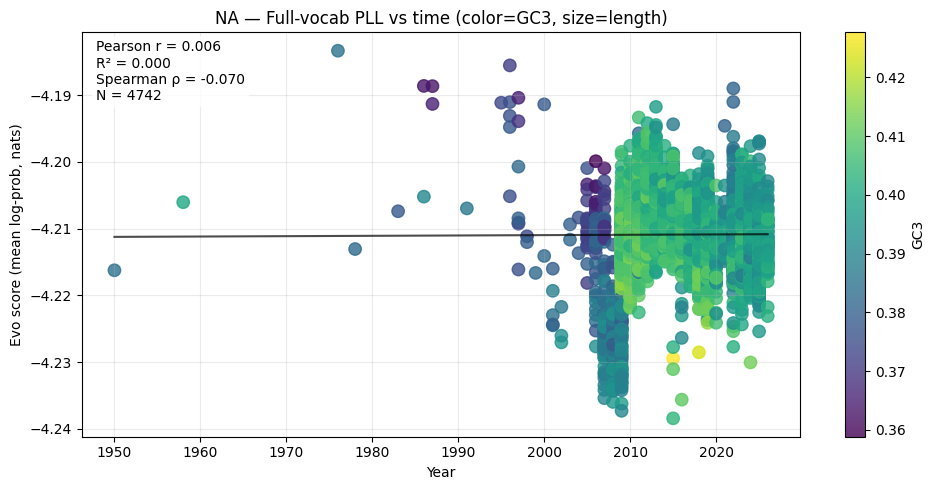

[OK] Saved np_evo_syn_constrained_vs_year.png


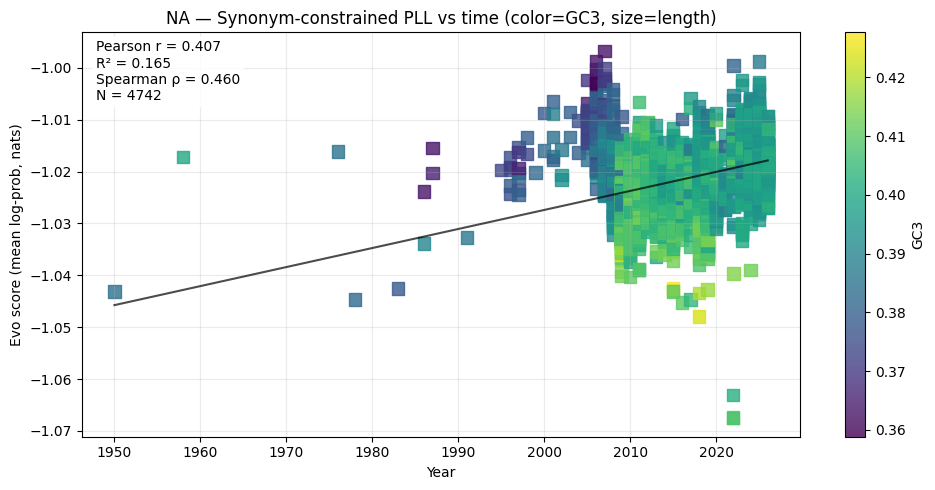

[OK] Saved np_evo_delta_vs_year.png


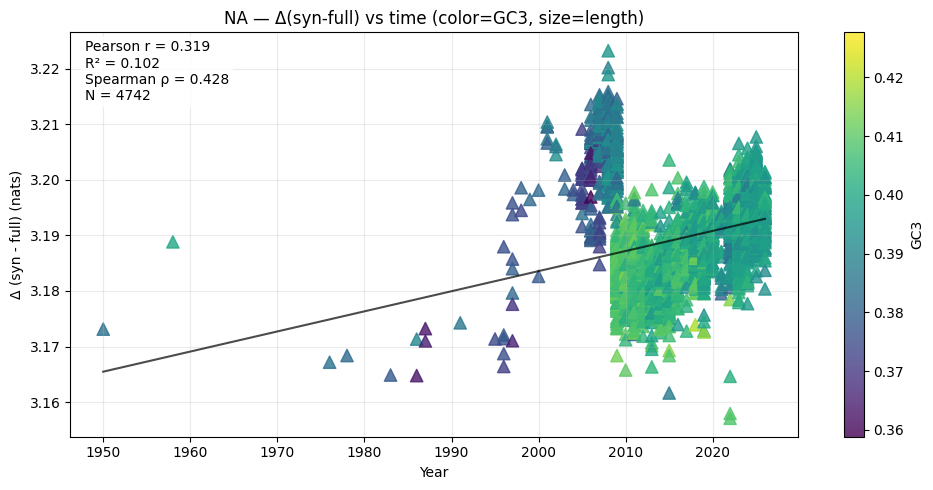

[INFO] Max year in df: 2026


In [3]:
# ===== Cell B: Separate plots with Pearson r, R², Spearman ρ + smaller points + strain annotations =====
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

# --- Controls (defined here to avoid NameError after kernel restart) ---
ANNOTATE_POINTS = True
MAX_ANNOTATIONS = 150

# --- Restrict plotting window ---
MIN_PLOT_YEAR = 1950
MAX_PLOT_YEAR = 2026

df_plot = df_plot[(df_plot["year"] >= MIN_PLOT_YEAR) & (df_plot["year"] <= MAX_PLOT_YEAR)].copy()

def _scatter_with_corr_stats(
    x, y, *,
    colors=None, sizes=None,
    labels=None,
    xlabel="", ylabel="", title="",
    marker="o", annotate=True,
    out_png=None
):
    """
    Scatter plot with linear fit + Pearson r, R², Spearman ρ.
    Annotates points with `labels` (same length as x/y), skipping blank labels.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x2 = x[mask]
    y2 = y[mask]

    c2 = np.asarray(colors, dtype=float)[mask] if colors is not None else None
    s2 = np.asarray(sizes, dtype=float)[mask] if sizes is not None else None
    lab2 = np.asarray(labels, dtype=object)[mask] if labels is not None else None

    # Stats
    if len(x2) >= 2:
        r, _ = pearsonr(x2, y2)
        rho, _ = spearmanr(x2, y2)
        lr = linregress(x2, y2)
        r2 = lr.rvalue ** 2
    else:
        r, rho, r2, lr = np.nan, np.nan, np.nan, None

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sc = ax.scatter(x2, y2, c=c2, s=s2, marker=marker, alpha=0.80)

    if c2 is not None:
        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label("GC3")

    if lr is not None:
        xfit = np.linspace(np.min(x2), np.max(x2), 200)
        yfit = lr.slope * xfit + lr.intercept
        ax.plot(xfit, yfit, color="black", lw=1.5, alpha=0.7)

    stats_txt = (
        f"Pearson r = {r:.3f}\n"
        f"R² = {r2:.3f}\n"
        f"Spearman ρ = {rho:.3f}\n"
        f"N = {len(x2)}"
    )
    ax.text(
        0.02, 0.98, stats_txt,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    # Annotate using labels, skipping blanks (so only Cali 04/2009 shows)
    if annotate and ANNOTATE_POINTS and lab2 is not None:
        n_anno = min(len(x2), MAX_ANNOTATIONS)
        for i in range(n_anno):
            txt = "" if lab2 is None else str(lab2[i]).strip()
            if (not txt) or (txt.lower() == "nan"):
                continue
            ax.annotate(
                txt,
                (float(x2[i]), float(y2[i])),
                textcoords="offset points",
                xytext=(4, 3),
                fontsize=7,
                alpha=0.75
            )

    plt.tight_layout()
    if out_png:
        plt.savefig(out_png, dpi=200)
        print(f"[OK] Saved {out_png}")
    plt.show()
    plt.close(fig)

# --- Build shared aesthetics ---
if df_plot.empty:
    print("[WARN] df_plot is empty; nothing to plot.")
else:
    x_year = df_plot["year"].astype(int).values

    # Smaller points: lower scale and baseline
    sizes = (df_plot["length_codons"].astype(float).values * 0.15) + 9.0
    colors = df_plot["gc3"].astype(float).values

    # IMPORTANT: use anno_label (blank for all except Cali 04/2009)
    labels = df_plot["anno_label"].astype(str).values

    # 1) Full-vocab PLL vs year
    _scatter_with_corr_stats(
        x_year,
        df_plot["evo_full_vocab_PLL"].astype(float).values,
        colors=colors,
        sizes=sizes,
        labels=labels,
        xlabel="Year",
        ylabel="Evo score (mean log-prob, nats)",
        title="NA — Full-vocab PLL vs time (color=GC3, size=length)",
        marker="o",
        annotate=True,
        out_png="np_evo_full_vocab_vs_year.png"
    )

    # 2) Synonym-constrained PLL vs year
    _scatter_with_corr_stats(
        x_year,
        df_plot["evo_synonym_constrained_PLL"].astype(float).values,
        colors=colors,
        sizes=sizes,
        labels=labels,
        xlabel="Year",
        ylabel="Evo score (mean log-prob, nats)",
        title="NA — Synonym-constrained PLL vs time (color=GC3, size=length)",
        marker="s",
        annotate=True,
        out_png="np_evo_syn_constrained_vs_year.png"
    )

    # 3) Delta vs year (optional)
    if "delta_syn_minus_full" in df_plot.columns:
        _scatter_with_corr_stats(
            x_year,
            df_plot["delta_syn_minus_full"].astype(float).values,
            colors=colors,
            sizes=sizes,
            labels=labels,
            xlabel="Year",
            ylabel="Δ (syn - full) (nats)",
            title="NA — Δ(syn-full) vs time (color=GC3, size=length)",
            marker="^",
            annotate=False,  # usually too busy for delta; set True if you want
            out_png="np_evo_delta_vs_year.png"
        )

    print("[INFO] Max year in df:", df["year"].max())

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[INFO] Retained 4733 sequences after filtering for 1300–1500 nt and years 1990–2026.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[OK] Saved np_evo_full_vocab_vs_year.svg


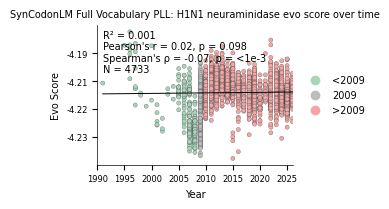

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[OK] Saved np_evo_syn_constrained_vs_year.svg


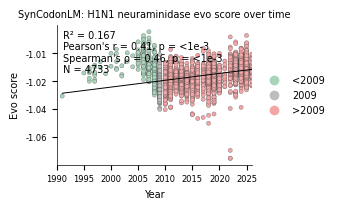

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[OK] Saved np_evo_delta_vs_year.svg


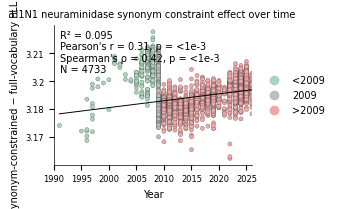

[INFO] Max year in original df: 2026
[INFO] Max year in filtered df_plot: 2026


In [11]:
# ===== Cell B: Nature-style SVG plots with script-1 styling applied to neuraminidase / 1300–1500 nt =====
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr, linregress

# --- Restrict plotting window ---
MIN_PLOT_YEAR = 1990
MAX_PLOT_YEAR = 2026

# --- Restrict nucleotide length window ---
MIN_LENGTH_NT = 1300
MAX_LENGTH_NT = 1500

# --- Make a working copy ---
df_plot = df_plot.copy()

# --- Determine nucleotide length column robustly ---
if "length_nt" in df_plot.columns:
    df_plot["_length_nt_for_filter"] = df_plot["length_nt"].astype(float)
elif "length_codons" in df_plot.columns:
    df_plot["_length_nt_for_filter"] = df_plot["length_codons"].astype(float) * 3
else:
    raise KeyError(
        "Could not find a length column. Expected either 'length_nt' or 'length_codons'."
    )

# --- Filter by year and nucleotide length BEFORE plotting/statistics ---
df_plot = df_plot[
    (df_plot["year"] >= MIN_PLOT_YEAR) &
    (df_plot["year"] <= MAX_PLOT_YEAR) &
    (df_plot["_length_nt_for_filter"] >= MIN_LENGTH_NT) &
    (df_plot["_length_nt_for_filter"] <= MAX_LENGTH_NT)
].copy()

print(
    f"[INFO] Retained {len(df_plot)} sequences after filtering "
    f"for {MIN_LENGTH_NT}–{MAX_LENGTH_NT} nt and years "
    f"{MIN_PLOT_YEAR}–{MAX_PLOT_YEAR}."
)

# --- Figure size from script 1 ---
MM_TO_INCH = 1 / 25.4
FIG_WIDTH_MM = 85.8
FIG_HEIGHT_MM = 52.8
FIGSIZE = (FIG_WIDTH_MM * MM_TO_INCH, FIG_HEIGHT_MM * MM_TO_INCH)

# --- Style from script 1 ---
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 7,
    "svg.fonttype": "none",
    "axes.linewidth": 0.5,
})

# --- Colors ---
PASTEL_GREEN = "#A8D5BA"
YEAR_GRAY    = "#BDBDBD"
PASTEL_RED   = "#F4A6A6"
EDGE_COLOR   = "#4A4A4A"
POINT_SIZE = 9


def _year_category_colors(years):
    years = np.asarray(years)
    out = np.empty(len(years), dtype=object)
    out[years < 2009] = PASTEL_GREEN
    out[years == 2009] = YEAR_GRAY
    out[years > 2009] = PASTEL_RED
    return out


def _format_p(p):
    if np.isnan(p):
        return "NA"
    elif p < 1e-3:
        return "<1e-3"
    else:
        return f"{p:.3f}"


def _scatter_with_corr_stats(
    x,
    y,
    *,
    point_colors=None,
    xlabel="",
    ylabel="",
    title="",
    out_svg=None
):
    """
    Plot styling matched to script 1.
    Data filtering retained from the neuraminidase / 1300–1500 nt script.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x2 = x[mask]
    y2 = y[mask]
    c2 = np.asarray(point_colors, dtype=object)[mask] if point_colors is not None else None

    # --- Stats ---
    if len(x2) >= 3:
        r, p_r = pearsonr(x2, y2)
        rho, p_rho = spearmanr(x2, y2)
        r2 = r ** 2
        lr = linregress(x2, y2)
    else:
        r = rho = r2 = p_r = p_rho = np.nan
        lr = None

    # --- Plot ---
    fig, ax = plt.subplots(figsize=FIGSIZE)

    ax.scatter(
        x2,
        y2,
        c=c2,
        s=POINT_SIZE,
        edgecolors=EDGE_COLOR,
        linewidths=0.2
    )

    if lr is not None:
        xfit = np.linspace(x2.min(), x2.max(), 200)
        ax.plot(
            xfit,
            lr.slope * xfit + lr.intercept,
            color="black",
            lw=0.7
        )

    # --- Stats text from script 1 ---
    stats_txt = (
        f"R² = {r2:.3f}\n"
        f"Pearson's r = {r:.2f}, p = {_format_p(p_r)}\n"
        f"Spearman's ρ = {rho:.2f}, p = {_format_p(p_rho)}\n"
        f"N = {len(x2)}"
    )

    ax.text(
        0.03, 0.97,
        stats_txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7
    )

    # --- Axes from script 1 ---
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    from matplotlib.ticker import FixedLocator, FuncFormatter
    def _fmt_max_2_decimals(x, pos):
        return f"{x:.2f}".rstrip("0").rstrip(".")


    # Get current y-limits
    ymin, ymax = ax.get_ylim()
    
    # Create 4 ticks INSIDE the range (exclude endpoints)
    yticks = np.linspace(ymin, ymax, 6)[1:-1]
    
    ax.yaxis.set_major_locator(FixedLocator(yticks))
    ax.yaxis.set_major_formatter(FuncFormatter(_fmt_max_2_decimals))

    ax.set_xlim(MIN_PLOT_YEAR, MAX_PLOT_YEAR)
    ax.set_xticks(np.arange(MIN_PLOT_YEAR, MAX_PLOT_YEAR + 1, 5))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --- Legend from script 1 ---
    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=PASTEL_GREEN, label="<2009"),
        Line2D([0], [0], marker="o", linestyle="", color=YEAR_GRAY, label="2009"),
        Line2D([0], [0], marker="o", linestyle="", color=PASTEL_RED, label=">2009"),
    ]

    ax.legend(
        handles=legend_handles,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout()

    if out_svg:
        fig.savefig(out_svg, format="svg")
        print(f"[OK] Saved {out_svg}")

    plt.show()
    plt.close(fig)


# ===== MAIN =====
if df_plot.empty:
    print("[WARN] df_plot is empty after year/length filtering; nothing to plot.")
else:
    x_year = df_plot["year"].astype(float).values
    point_colors = _year_category_colors(x_year)

    # 1) Full-vocabulary PLL vs year
    _scatter_with_corr_stats(
        x_year,
        df_plot["evo_full_vocab_PLL"].astype(float).values,
        point_colors=point_colors,
        xlabel="Year",
        ylabel="Evo Score",
        title="SynCodonLM Full Vocabulary PLL: H1N1 neuraminidase evo score over time",
        out_svg="np_evo_full_vocab_vs_year.svg"
    )

    # 2) Synonym-constrained PLL vs year
    _scatter_with_corr_stats(
        x_year,
        df_plot["evo_synonym_constrained_PLL"].astype(float).values,
        point_colors=point_colors,
        xlabel="Year",
        ylabel="Evo score",
        title="SynCodonLM: H1N1 neuraminidase evo score over time",
        out_svg="np_evo_syn_constrained_vs_year.svg"
    )

    # 3) Delta vs year, if available
    if "delta_syn_minus_full" in df_plot.columns:
        _scatter_with_corr_stats(
            x_year,
            df_plot["delta_syn_minus_full"].astype(float).values,
            point_colors=point_colors,
            xlabel="Year",
            ylabel="Δ synonym-constrained − full-vocabulary PLL (nats)",
            title="H1N1 neuraminidase synonym constraint effect over time",
            out_svg="np_evo_delta_vs_year.svg"
        )

    print("[INFO] Max year in original df:", df["year"].max())
    print("[INFO] Max year in filtered df_plot:", df_plot["year"].max())

In [6]:
# ===== ESM-2 protein PLL/PPPL using protein_sequence from UNDROPPED sequences CSV =====
import os
import numpy as np
import torch
import pandas as pd
from tqdm.auto import tqdm

# ------------------ Inputs / Outputs ------------------
OUTPUT_XLSX = "np_evo_scores-ncbidataset-h1n1-NA.xlsx"
KEPT_CSV    = "np_undropped_sequences-ncbidataset-h1n1-NA.csv"  # produced by SynCodonLM filtering script
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Read Scores sheet explicitly
df = pd.read_excel(OUTPUT_XLSX, sheet_name="Scores")
kept = pd.read_csv(KEPT_CSV)

# Optional: if your Scores has subtype, keep only H3N2 rows (matches first script intent)
if "subtype" in df.columns:
    df = df[df["subtype"].astype(str).str.upper().eq("H1N1")].copy()

# --- WARNING: disables SSL verification (insecure). Use only temporarily. ---
for k in ["REQUESTS_CA_BUNDLE", "CURL_CA_BUNDLE", "SSL_CERT_FILE"]:
    os.environ.pop(k, None)

import requests
from huggingface_hub import configure_http_backend

def backend_factory() -> requests.Session:
    s = requests.Session()
    s.verify = False
    return s

configure_http_backend(backend_factory=backend_factory)

try:
    import urllib3
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
except Exception:
    pass

from transformers import AutoTokenizer, AutoModelForMaskedLM

# ------------------ choose your checkpoint ------------------
ESM2_MODEL_NAME = "facebook/esm2_t30_150M_UR50D"   # or "facebook/esm2_t33_650M_UR50D"
ESM2_DEVICE = DEVICE
ESM2_CHUNK  = 1024
# -----------------------------------------------------------

# ------------------ Fallback translation (only used if protein_sequence missing) ------------------
CODON_TABLE = {
    "TTT":"F","TTC":"F","TTA":"L","TTG":"L",
    "TCT":"S","TCC":"S","TCA":"S","TCG":"S",
    "TAT":"Y","TAC":"Y","TAA":"*","TAG":"*",
    "TGT":"C","TGC":"C","TGA":"*","TGG":"W",
    "CTT":"L","CTC":"L","CTA":"L","CTG":"L",
    "CCT":"P","CCC":"P","CCA":"P","CCG":"P",
    "CAT":"H","CAC":"H","CAA":"Q","CAG":"Q",
    "CGT":"R","CGC":"R","CGA":"R","CGG":"R",
    "ATT":"I","ATC":"I","ATA":"I","ATG":"M",
    "ACT":"T","ACC":"T","ACA":"T","ACG":"T",
    "AAT":"N","AAC":"N","AAA":"K","AAG":"K",
    "AGT":"S","AGC":"S","AGA":"R","AGG":"R",
    "GTT":"V","GTC":"V","GTA":"V","GTG":"V",
    "GCT":"A","GCC":"A","GCA":"A","GCG":"A",
    "GAT":"D","GAC":"D","GAA":"E","GAG":"E",
    "GGT":"G","GGC":"G","GGA":"G","GGG":"G",
}
STOP_CODONS = {"TAA", "TAG", "TGA"}

def clean_dna(seq: str) -> str:
    if not isinstance(seq, str):
        return ""
    return "".join(seq.split()).upper().replace("U", "T")

def translate_cds_to_protein_strict(dna: str) -> str:
    dna = clean_dna(dna)
    if not dna or (len(dna) % 3 != 0):
        return ""
    if any(b not in "ACGT" for b in dna):
        return ""

    codons = [dna[i:i+3] for i in range(0, len(dna), 3)]
    if codons[0] != "ATG":
        return ""
    if codons[-1] not in STOP_CODONS:
        return ""

    aa = []
    for c in codons[:-1]:  # exclude terminal stop
        a = CODON_TABLE.get(c)
        if a is None or a == "*":
            return ""
        aa.append(a)
    return "".join(aa)
# -----------------------------------------------------------------------------------------------

# ------------------ Build accession -> protein map from KEPT_CSV ------------------
if "accession" not in kept.columns:
    raise ValueError(f"{KEPT_CSV} must contain an 'accession' column.")

use_protein_column = "protein_sequence" in kept.columns

if use_protein_column:
    # Best path: use protein_sequence already computed by your first script
    acc2prot = dict(zip(
        kept["accession"].astype(str),
        kept["protein_sequence"].fillna("").astype(str).str.strip()
    ))
else:
    # Fallback: derive proteins from DNA as you originally did
    if "dna" not in kept.columns:
        raise ValueError(f"{KEPT_CSV} must contain either 'protein_sequence' or 'dna'.")
    acc2prot = {}
    for acc, dna in zip(kept["accession"].astype(str), kept["dna"].astype(str)):
        acc2prot[acc] = translate_cds_to_protein_strict(dna)

# Align proteins to Scores rows (Scores sheet)
if "accession" not in df.columns:
    raise ValueError("Scores sheet must contain an 'accession' column.")

protein_seqs = df["accession"].astype(str).map(acc2prot).fillna("").tolist()

missing = sum(1 for s in protein_seqs if not s)
print(f"[INFO] Using {'kept.protein_sequence' if use_protein_column else 'strict DNA translation'}; "
      f"blank protein for {missing}/{len(protein_seqs)} row(s).")

# ------------------ ESM-2 PLL scoring ------------------
@torch.no_grad()
def esm2_pll_for_sequence(protein_seq: str, tokenizer, model, chunk_size: int = 256):
    protein_seq = protein_seq.strip().upper()
    if len(protein_seq) == 0:
        return (float("nan"), float("nan"), float("nan"))

    enc = tokenizer(protein_seq, return_tensors="pt", add_special_tokens=True)
    input_ids = enc["input_ids"].to(ESM2_DEVICE)
    attention_mask = enc["attention_mask"].to(ESM2_DEVICE)

    mask_id = tokenizer.mask_token_id
    if mask_id is None:
        raise ValueError("Tokenizer has no mask_token_id; cannot compute masked PLL.")

    L = input_ids.size(1)
    pos = torch.arange(1, L - 1, device=ESM2_DEVICE, dtype=torch.long)  # exclude BOS/EOS
    n = pos.numel()
    if n <= 0:
        return (float("nan"), float("nan"), float("nan"))

    targets = input_ids[0, pos].clone()
    pll_sum = 0.0

    for start in range(0, n, chunk_size):
        end = min(n, start + chunk_size)
        pos_chunk = pos[start:end]
        bsz = pos_chunk.numel()

        ids_rep = input_ids.repeat(bsz, 1)
        attn_rep = attention_mask.repeat(bsz, 1)

        row_idx = torch.arange(bsz, device=ESM2_DEVICE)
        ids_rep[row_idx, pos_chunk] = mask_id

        logits = model(input_ids=ids_rep, attention_mask=attn_rep).logits
        log_probs = torch.log_softmax(logits.float(), dim=-1)

        targ_chunk = targets[start:end]
        lp = log_probs[row_idx, pos_chunk, targ_chunk]
        pll_sum += float(lp.sum().item())

    avg_logp = pll_sum / float(n)
    pppl = float(np.exp(-avg_logp))
    return (pll_sum, avg_logp, pppl)

print(f"[ESM2] Loading {ESM2_MODEL_NAME} ...")
esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
esm2_model = AutoModelForMaskedLM.from_pretrained(ESM2_MODEL_NAME).to(ESM2_DEVICE).eval()

esm2_pll, esm2_avg, esm2_pppl = [], [], []
scored_missing = 0

print("[ESM2] Scoring proteins with masked PLL (protein excludes terminal stop)...")
for s in tqdm(protein_seqs, desc="ESM2 PLL (protein)", unit="seq"):
    if not s:
        scored_missing += 1
        esm2_pll.append(float("nan"))
        esm2_avg.append(float("nan"))
        esm2_pppl.append(float("nan"))
        continue
    pll_sum, avg_logp, pppl = esm2_pll_for_sequence(
        s, esm2_tokenizer, esm2_model, chunk_size=ESM2_CHUNK
    )
    esm2_pll.append(pll_sum)
    esm2_avg.append(avg_logp)
    esm2_pppl.append(pppl)

df["esm2_model_name"] = ESM2_MODEL_NAME
df["esm2_protein_seq_source"] = "kept.protein_sequence" if use_protein_column else "strict_translate_from_kept.dna"
df["esm2_protein_seq"] = protein_seqs
df["esm2_protein_PLL"] = esm2_pll
df["esm2_protein_avg_logp_per_residue"] = esm2_avg
df["esm2_protein_PPPL"] = esm2_pppl

print(f"[OK] Added ESM-2 columns to df. Blank protein for {scored_missing} row(s).")

# ---- Write back into the same Excel without deleting other sheets ----
df_out = df.copy()
if "year" in df_out.columns and "accession" in df_out.columns:
    df_out = df_out.sort_values(["year", "accession"], na_position="last")

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_out.to_excel(writer, index=False, sheet_name="Scores")

print(f"[OK] Updated '{OUTPUT_XLSX}' sheet 'Scores' with ESM-2 columns (other sheets preserved).")

[INFO] Using kept.protein_sequence; blank protein for 0/4744 row(s).
[ESM2] Loading facebook/esm2_t30_150M_UR50D ...
[ESM2] Scoring proteins with masked PLL (protein excludes terminal stop)...


ESM2 PLL (protein):   0%|          | 0/4744 [00:00<?, ?seq/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[OK] Saved np_esm2_avg_logp_vs_year_1990_2026.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

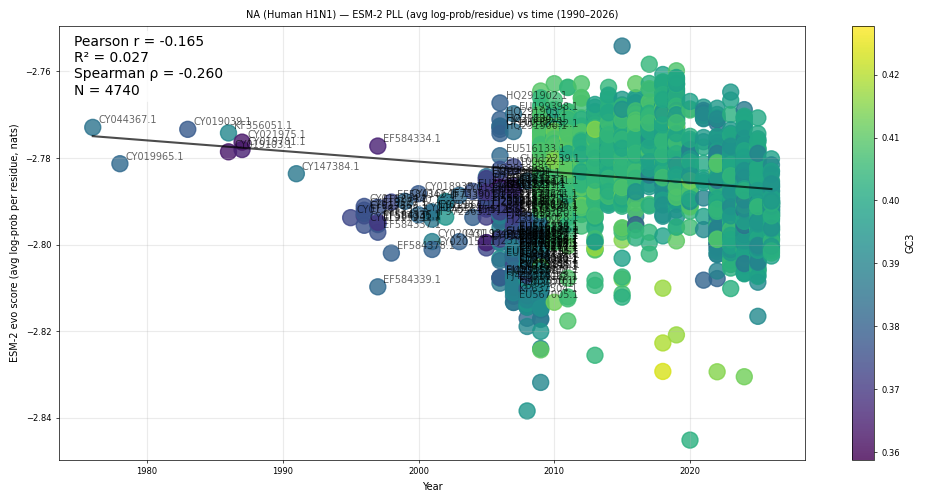

In [7]:
# -------------------- Plotting (ESM evo score + year filter) --------------------
import numpy as np
from scipy.stats import pearsonr, spearmanr, linregress
import matplotlib.pyplot as plt
# Defaults if these were defined in your original script but not in this notebook session
ANNOTATE_POINTS = globals().get("ANNOTATE_POINTS", False)
MAX_ANNOTATIONS = globals().get("MAX_ANNOTATIONS", 150)
def scatter_with_corr_stats(
    x, y, *,
    labels=None,
    colors=None,
    sizes=None,
    xlabel="",
    ylabel="",
    title="",
    marker="o",
    annotate_points=False,
    max_annotations=150,
    colorbar_label="GC3",
    out_png=None,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    labels_f = None
    if labels is not None:
        labels_f = np.asarray(labels, dtype=object)[mask]

    c = None
    if colors is not None:
        c = np.asarray(colors, dtype=float)[mask]

    s = None
    if sizes is not None:
        s = np.asarray(sizes, dtype=float)[mask]

    # Stats (guard for small N)
    if len(x) >= 2:
        pr, _ = pearsonr(x, y)
        sr, _ = spearmanr(x, y)
        lr = linregress(x, y)
        r2 = lr.rvalue ** 2
    else:
        pr, sr, r2 = np.nan, np.nan, np.nan
        lr = None

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    sc = ax.scatter(
        x, y,
        c=c,
        s=s,
        marker=marker,
        alpha=0.80,
    )

    if c is not None:
        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label(colorbar_label)

    if lr is not None:
        xfit = np.linspace(np.min(x), np.max(x), 200)
        yfit = lr.slope * xfit + lr.intercept
        ax.plot(xfit, yfit, color="black", lw=1.5, alpha=0.70)

    stats_txt = (
        f"Pearson r = {pr:.3f}\n"
        f"R² = {r2:.3f}\n"
        f"Spearman ρ = {sr:.3f}\n"
        f"N = {len(x)}"
    )
    ax.text(
        0.02, 0.98, stats_txt,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    if annotate_points and labels_f is not None and len(labels_f) > 0:
        n_anno = min(len(labels_f), int(max_annotations))
        for i in range(n_anno):
            ax.annotate(
                str(labels_f[i]),
                (x[i], y[i]),
                textcoords="offset points",
                xytext=(4, 3),
                fontsize=7,
                alpha=0.60,
            )

    plt.tight_layout()
    if out_png:
        plt.savefig(out_png, dpi=200)
        print(f"[OK] Saved {out_png}")
    plt.show()
    plt.close(fig)


# --- Plot: Year vs ESM evo score ---
# Use avg log-prob per residue: closest analogue to your "mean log-prob" evo score.
ESM_COL = "esm2_protein_avg_logp_per_residue"

# Filter to rows that have year and ESM score
df_plot = df.dropna(subset=["year", ESM_COL]).copy()
df_plot = df_plot[(df_plot["year"] >= 1968) & (df_plot["year"] <= 2026)].sort_values("year")

if df_plot.empty:
    print(f"[WARN] No rows with year in [1990, 2026] and non-null {ESM_COL}; skipping plots.")
else:
    years = df_plot["year"].astype(int).values

    # Keep your existing aesthetics
    sizes = (df_plot["length_codons"].astype(float).values * 0.25) + 15.0 if "length_codons" in df_plot.columns else None
    colors = df_plot["gc3"].astype(float).values if "gc3" in df_plot.columns else None
    labels = df_plot["accession"].astype(str).values if "accession" in df_plot.columns else None

    scatter_with_corr_stats(
        years,
        df_plot[ESM_COL].astype(float).values,
        labels=labels,
        colors=colors,
        sizes=sizes,
        xlabel="Year",
        ylabel="ESM-2 evo score (avg log-prob per residue, nats)",
        title="NA (Human H1N1) — ESM-2 PLL (avg log-prob/residue) vs time (1990–2026)",
        marker="o",
        annotate_points=bool(ANNOTATE_POINTS),
        max_annotations=MAX_ANNOTATIONS,
        out_png="np_esm2_avg_logp_vs_year_1990_2026.png",
    )

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[INFO] Retained 4733 sequences after filtering for 1300–1500 nt, years 1990–2026, and non-null esm2_protein_avg_logp_per_residue.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[OK] Saved np_esm2_avg_logp_vs_year.svg


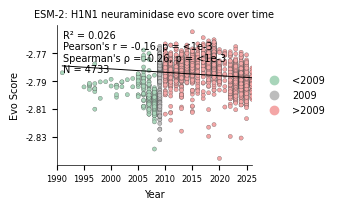

[INFO] Max year in original df: 2026
[INFO] Max year in filtered df_plot: 2026


In [13]:
# ===== ESM plot using the SAME graph formatting/style as the SynCodonLM plots =====

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr, linregress
from matplotlib.ticker import FixedLocator, FuncFormatter

# -------------------- User settings --------------------

# --- Restrict plotting window ---
MIN_PLOT_YEAR = 1990
MAX_PLOT_YEAR = 2026

# --- Restrict nucleotide length window ---
MIN_LENGTH_NT = 1300
MAX_LENGTH_NT = 1500

# --- ESM score column ---
ESM_COL = "esm2_protein_avg_logp_per_residue"

# -------------------- Figure size (copied from first script) --------------------

MM_TO_INCH = 1 / 25.4
FIG_WIDTH_MM = 85.8
FIG_HEIGHT_MM = 52.8
FIGSIZE = (FIG_WIDTH_MM * MM_TO_INCH, FIG_HEIGHT_MM * MM_TO_INCH)

# -------------------- Style (copied from first script) --------------------

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 7,
    "svg.fonttype": "none",
    "axes.linewidth": 0.5,
})

# -------------------- Colors (copied from first script) --------------------

PASTEL_GREEN = "#A8D5BA"
YEAR_GRAY    = "#BDBDBD"
PASTEL_RED   = "#F4A6A6"
EDGE_COLOR   = "#4A4A4A"
POINT_SIZE   = 9

# -------------------- Helper functions --------------------

def _year_category_colors(years):
    years = np.asarray(years)
    out = np.empty(len(years), dtype=object)
    out[years < 2009] = PASTEL_GREEN
    out[years == 2009] = YEAR_GRAY
    out[years > 2009] = PASTEL_RED
    return out


def _format_p(p):
    if np.isnan(p):
        return "NA"
    elif p < 1e-3:
        return "<1e-3"
    else:
        return f"{p:.3f}"


def _scatter_with_corr_stats(
    x, y,
    *,
    point_colors=None,
    xlabel="",
    ylabel="",
    title="",
    out_svg=None
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)

    x2 = x[mask]
    y2 = y[mask]
    c2 = point_colors[mask] if point_colors is not None else None

    # --- Stats ---
    if len(x2) >= 3:
        r, p_r = pearsonr(x2, y2)
        rho, p_rho = spearmanr(x2, y2)
        r2 = r ** 2
        lr = linregress(x2, y2)
    else:
        r = rho = r2 = p_r = p_rho = np.nan
        lr = None

    # --- Plot ---
    fig, ax = plt.subplots(figsize=FIGSIZE)

    ax.scatter(
        x2, y2,
        c=c2,
        s=POINT_SIZE,
        edgecolors=EDGE_COLOR,
        linewidths=0.2
    )

    if lr:
        xfit = np.linspace(x2.min(), x2.max(), 200)
        ax.plot(xfit, lr.slope * xfit + lr.intercept, color="black", lw=0.7)

    # --- Stats box (same format as first script) ---
    stats_txt = (
        f"R² = {r2:.3f}\n"
        f"Pearson's r = {r:.2f}, p = {_format_p(p_r)}\n"
        f"Spearman's ρ = {rho:.2f}, p = {_format_p(p_rho)}\n"
        f"N = {len(x2)}"
    )

    ax.text(
        0.03, 0.97,
        stats_txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7,
    )

    # --- Axes ---
    ax.set_xlabel(xlabel)
    ax.set_xlim(MIN_PLOT_YEAR, MAX_PLOT_YEAR)
    ax.set_xticks(np.arange(MIN_PLOT_YEAR, MAX_PLOT_YEAR + 1, 5))

    def _fmt_max_2_decimals(val, pos):
        return f"{val:.2f}".rstrip("0").rstrip(".")

    ymin, ymax = ax.get_ylim()
    yticks = np.linspace(ymin, ymax, 6)[1:-1]

    ax.yaxis.set_major_locator(FixedLocator(yticks))
    ax.yaxis.set_major_formatter(FuncFormatter(_fmt_max_2_decimals))

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --- Legend (same style as first script) ---
    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=PASTEL_GREEN, label="<2009"),
        Line2D([0], [0], marker="o", linestyle="", color=YEAR_GRAY, label="2009"),
        Line2D([0], [0], marker="o", linestyle="", color=PASTEL_RED, label=">2009"),
    ]

    ax.legend(
        handles=legend_handles,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout()

    if out_svg:
        fig.savefig(out_svg, format="svg")
        print(f"[OK] Saved {out_svg}")

    plt.show()
    plt.close()


# -------------------- Make working copy and filter --------------------

df_plot = df.copy()

if "length_nt" in df_plot.columns:
    df_plot["_length_nt_for_filter"] = df_plot["length_nt"].astype(float)
elif "length_codons" in df_plot.columns:
    df_plot["_length_nt_for_filter"] = df_plot["length_codons"].astype(float) * 3
else:
    raise KeyError(
        "Could not find a length column. Expected either 'length_nt' or 'length_codons'."
    )

if ESM_COL not in df_plot.columns:
    raise KeyError(f"Could not find ESM score column: {ESM_COL}")

df_plot = df_plot.dropna(subset=["year", ESM_COL]).copy()

df_plot = df_plot[
    (df_plot["year"] >= MIN_PLOT_YEAR) &
    (df_plot["year"] <= MAX_PLOT_YEAR) &
    (df_plot["_length_nt_for_filter"] >= MIN_LENGTH_NT) &
    (df_plot["_length_nt_for_filter"] <= MAX_LENGTH_NT)
].copy()

df_plot = df_plot.sort_values("year")

print(
    f"[INFO] Retained {len(df_plot)} sequences after filtering "
    f"for {MIN_LENGTH_NT}–{MAX_LENGTH_NT} nt, years "
    f"{MIN_PLOT_YEAR}–{MAX_PLOT_YEAR}, and non-null {ESM_COL}."
)

# -------------------- Build plot --------------------

if df_plot.empty:
    print(
        f"[WARN] df_plot is empty after filtering for "
        f"{MIN_LENGTH_NT}–{MAX_LENGTH_NT} nt, years "
        f"{MIN_PLOT_YEAR}–{MAX_PLOT_YEAR}, and non-null {ESM_COL}; nothing to plot."
    )
else:
    x_year = df_plot["year"].astype(float).values
    point_colors = _year_category_colors(x_year)

    _scatter_with_corr_stats(
        x_year,
        df_plot[ESM_COL].astype(float).values,
        point_colors=point_colors,
        xlabel="Year",
        ylabel="Evo Score",
        title="ESM-2: H1N1 neuraminidase evo score over time",
        out_svg="np_esm2_avg_logp_vs_year.svg"
    )

    print("[INFO] Max year in original df:", df["year"].max())
    print("[INFO] Max year in filtered df_plot:", df_plot["year"].max())